# <center>`Telecommunications Churn Classifier`</center>

## Column Descriptions

- **customerID**: Unique identifier assigned to each customer.

- **gender**: Indicates the customer's gender (Male or Female).

- **SeniorCitizen**: Indicates whether the customer is a senior citizen (1 = Yes, 0 = No).

- **Partner**: Indicates whether the customer has a partner (Yes or No).

- **Dependents**: Indicates whether the customer has dependents (Yes or No).

- **tenure**: Number of months the customer has been with the company.

- **PhoneService**: Indicates whether the customer has a phone service (Yes or No).

- **MultipleLines**: Indicates whether the customer has multiple phone lines (Yes, No, or No phone service).

- **InternetService**: Type of internet service used by the customer (DSL, Fiber optic, or No).

- **OnlineSecurity**: Indicates whether the customer has online security (Yes, No, or No internet service).

- **OnlineBackup**: Indicates whether the customer has online backup (Yes, No, or No internet service).

- **DeviceProtection**: Indicates whether the customer has device protection (Yes, No, or No internet service).

- **TechSupport**: Indicates whether the customer has technical support (Yes, No, or No internet service).

- **StreamingTV**: Indicates whether the customer uses streaming TV services (Yes, No, or No internet service).

- **StreamingMovies**: Indicates whether the customer uses streaming movie services (Yes, No, or No internet service).

- **Contract**: Specifies the type of contract (Month-to-month, One year, or Two year).

- **PaperlessBilling**: Indicates whether the customer uses paperless billing (Yes or No).

- **PaymentMethod**: Specifies the payment method (Electronic check, Mailed check, Bank transfer, or Credit card).

- **MonthlyCharges**: The amount charged to the customer on a monthly basis.

- **TotalCharges**: The total amount charged to the customer over the entire period.

- **Churn**: Indicates whether the customer has left the company (Yes or No).

## `Objectives` 
* 1- Data Preprocessing (encoding & scaling , oversampling , undersampling , featureselection)
* 2- Build Machine Learning Models to predict if person Churn or not
* 3- Model Selection and Tuning 

## Import Some Helper Library

In [31]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# For ML
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , StandardScaler , RobustScaler , MinMaxScaler , PolynomialFeatures
from sklearn.pipeline import Pipeline , make_pipeline
from datasist.structdata import detect_outliers
from sklearn.impute import SimpleImputer , KNNImputer
from category_encoders import BinaryEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import *
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , VotingClassifier , BaggingClassifier ,GradientBoostingClassifier,AdaBoostClassifier
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score ,recall_score,precision_score,f1_score ,confusion_matrix , ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate , cross_val_predict , GridSearchCV, RandomizedSearchCV , StratifiedKFold
from sklearn.compose import ColumnTransformer
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.pipeline import make_pipeline
from imblearn.under_sampling import RandomUnderSampler
import copy
import joblib




## Read and OverView data

In [2]:
df=pd.read_csv('Telco_Customer_Churn_Modified.csv')

In [3]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,NO,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,NO,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,NO,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,NO,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,NO,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7005,Male,NO,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7006,Female,NO,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7007,Female,NO,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7008,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7009,Male,NO,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   object 
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 


## Features Engineer

In [6]:
df['ChargeTenureRatio'] = df['MonthlyCharges'] / (df['tenure'] + 1)
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['IsNewCustomer'] = (df['tenure'] < 12).astype(int)

## Data Splitting and distribution visualization

In [7]:
x , y = df.drop(columns='Churn') , df['Churn']

In [8]:
y = y.map({'No': 0, 'Yes': 1})

In [9]:
df['Churn'].value_counts()
# inbalanced data

Churn
No     5153
Yes    1857
Name: count, dtype: int64

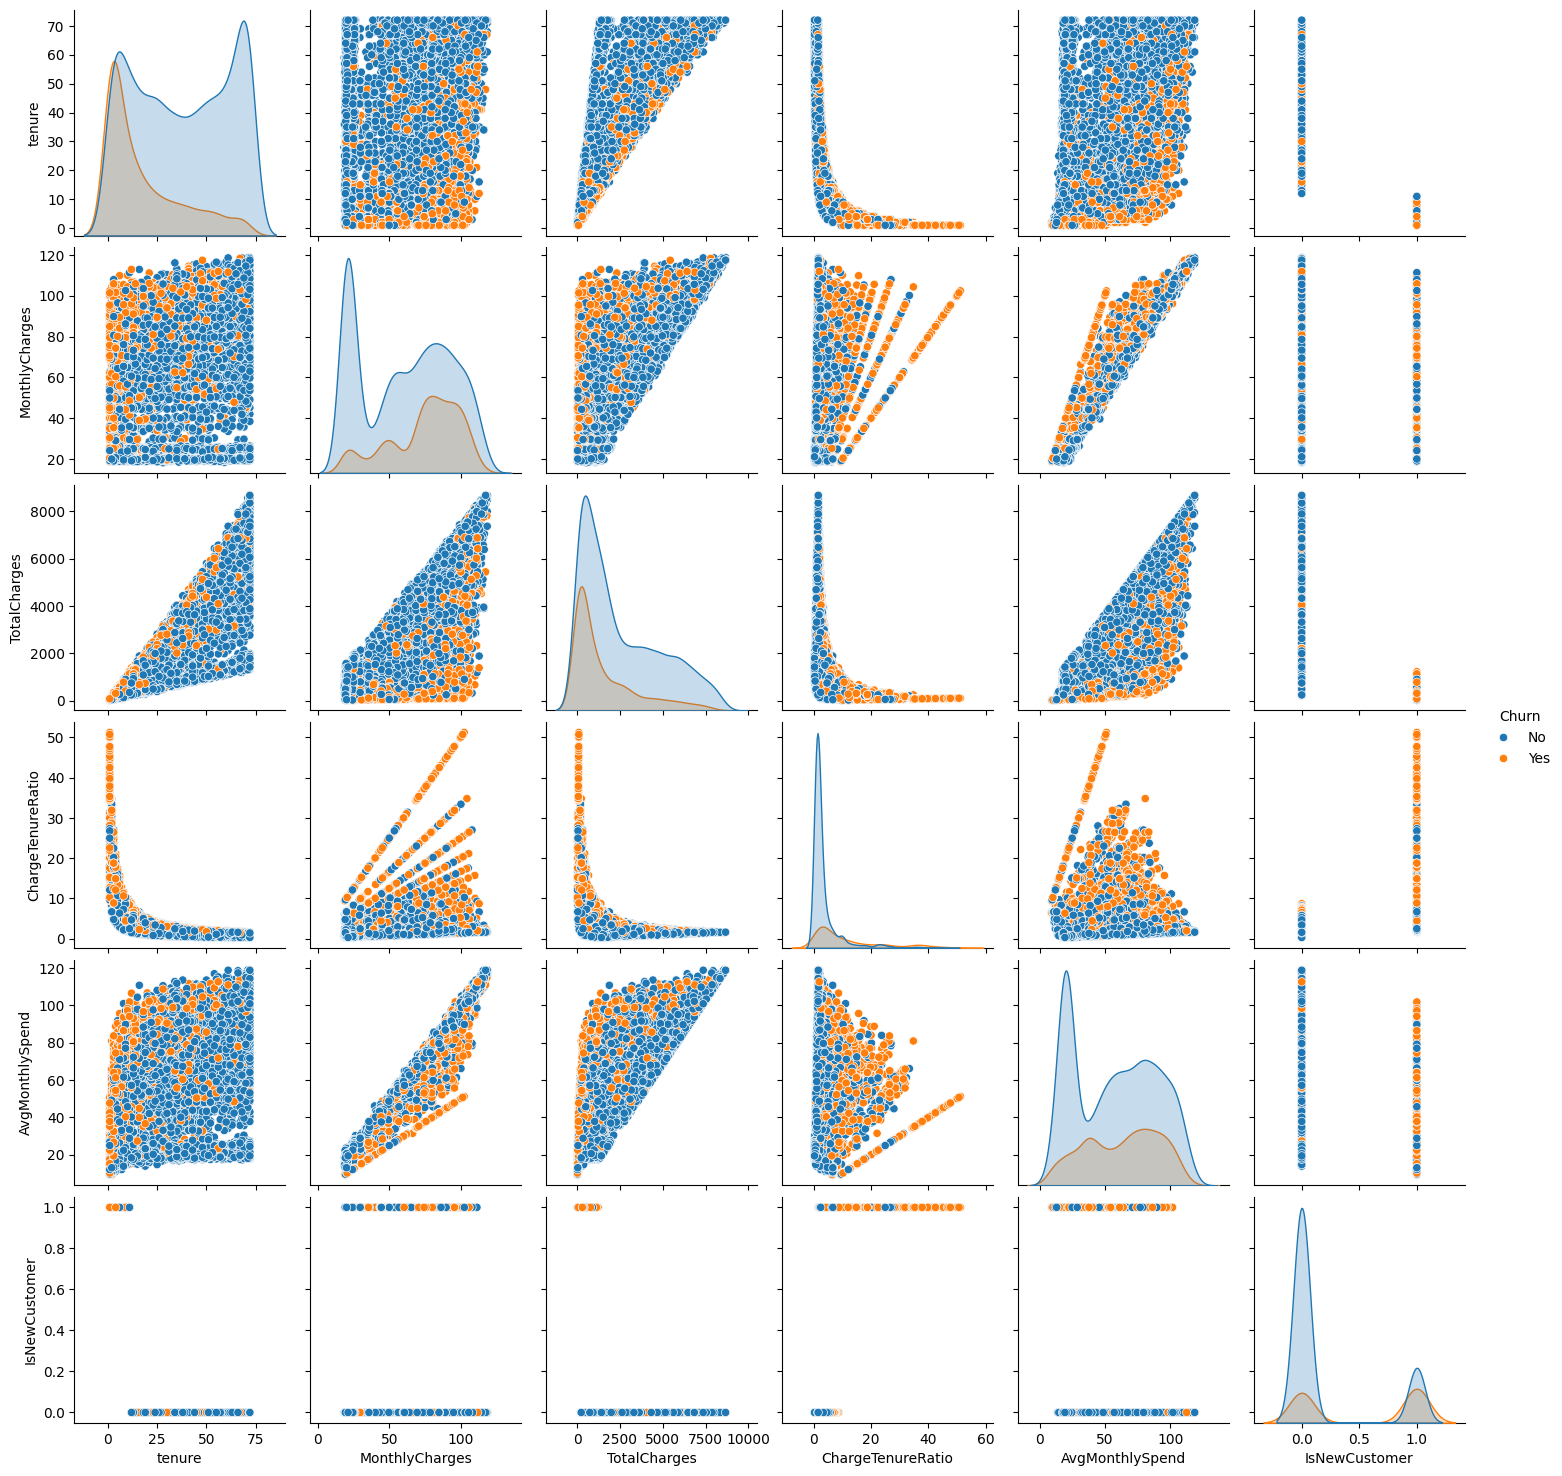

In [10]:
sns.pairplot(df,hue='Churn')

## Feature Selection

                                  feature  importance  importance_percent
3                       ChargeTenureRatio    0.352670           35.267008
4                         AvgMonthlySpend    0.113206           11.320647
2                            TotalCharges    0.108940           10.893985
1                          MonthlyCharges    0.108842           10.884183
13            InternetService_Fiber optic    0.040231            4.023062
0                                  tenure    0.029258            2.925840
31         PaymentMethod_Electronic check    0.026377            2.637737
9                          Dependents_Yes    0.024156            2.415582
8                             Partner_Yes    0.020510            2.050956
29                   PaperlessBilling_Yes    0.019460            1.946007
16                     OnlineSecurity_Yes    0.016979            1.697950
7                       SeniorCitizen_Yes    0.015809            1.580913
22                        TechSupport_

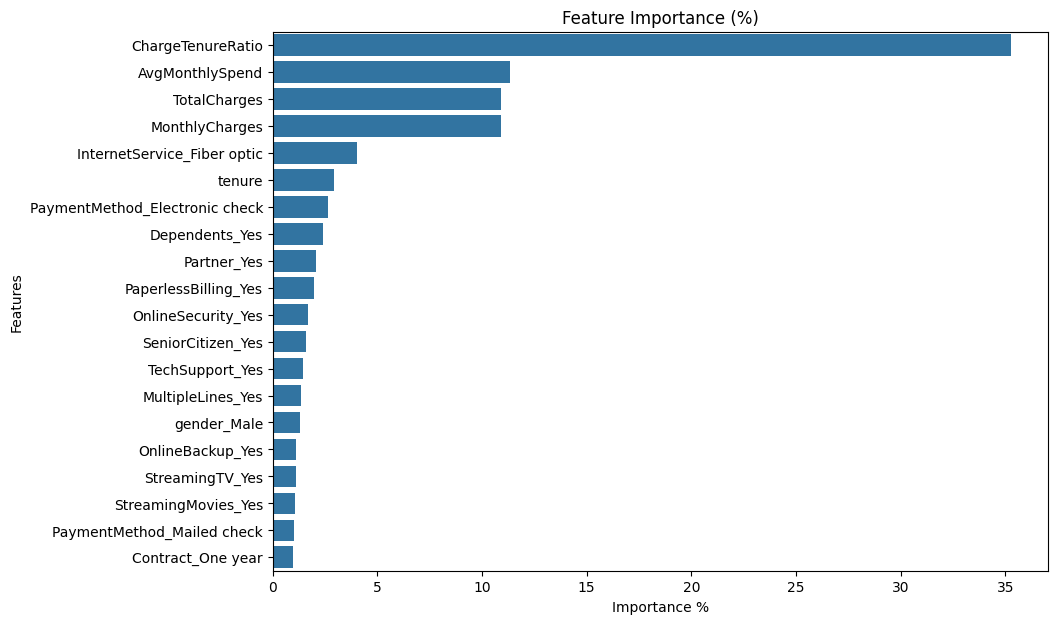

In [11]:
X_temp = x.copy()

cat_cols = X_temp.select_dtypes(include='object').columns

X_temp = pd.get_dummies(
    X_temp,
    columns=cat_cols,
    drop_first=True
)


dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_temp, y)


importance_df = pd.DataFrame({
    "feature": X_temp.columns,
    "importance": dt.feature_importances_
})

importance_df["importance_percent"] = (
    importance_df["importance"] /
    importance_df["importance"].sum()
) * 100

importance_df = importance_df.sort_values(
    by="importance_percent",
    ascending=False
)

print(importance_df)

plt.figure(figsize=(10,7))

sns.barplot(
    data=importance_df.head(20),
    y="feature",
    x="importance_percent"
)

plt.title("Feature Importance (%)")
plt.xlabel("Importance %")
plt.ylabel("Features")

plt.show()

In [12]:
# Removed engineered features that did not improve model performance;
# original features were more informative for churn prediction.

x.drop(
    columns=[
        'ChargeTenureRatio',
        'AvgMonthlySpend',
        'IsNewCustomer'
    ],
    inplace=True
)

## Data Preprocessing

In [13]:
# For encoding we need to know for each categorical column how many categories it has

for col in x.select_dtypes('O').columns:
    print(col)
    print(x[col].unique())
    print('==========================================')

gender
['Female' 'Male']
SeniorCitizen
['NO' 'Yes']
Partner
['Yes' 'No']
Dependents
['No' 'Yes']
PhoneService
['No' 'Yes']
MultipleLines
['No phone service' 'No' 'Yes']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['Yes' 'No' 'No internet service']
DeviceProtection
['No' 'Yes' 'No internet service']
TechSupport
['No' 'Yes' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['Month-to-month' 'One year' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [14]:
# For encoding we need to know for each categorical column how many categories it has

for col in x.select_dtypes('number').columns:
    print(col)
    print(x[col].unique())
    print('==========================================')

tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
MonthlyCharges
[29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges
[  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]


In [15]:
# Categorical Columns Pipeline
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_pipeline = Pipeline( [('OHE', ohe)] )
cat_col = x.select_dtypes('O').columns

In [16]:
# Scaling numerical Columns Pipeline
scaler = MinMaxScaler()
sclr_pipeline = Pipeline( [('SCALER', scaler)] )
num_col = x.select_dtypes('number').columns

In [17]:
preprocessing = ColumnTransformer(transformers= [ 
                                                  ('Categorical Pipeline', ohe_pipeline, cat_col),
                                                  ('numerical Pipeline', sclr_pipeline, num_col),
                                                  ])
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Categorical Pipeline', ...), ('numerical Pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_nam

## Model Selection

In [18]:
models = [

    LogisticRegression(class_weight='balanced'),
    KNeighborsClassifier(),
    GaussianNB(),
    MultinomialNB(),
    BernoulliNB(),
    ComplementNB(),
    CategoricalNB(),
    SVC(kernel='linear'),
    SVC(kernel='rbf'),
    SVC(kernel='poly'),
    SVC(kernel='sigmoid'),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    AdaBoostClassifier(),
    GradientBoostingClassifier(),
    XGBClassifier(),
]


LogisticRegression(class_weight='balanced')
Avg. Train Score: 0.7535306704707561
Avg. Test Score: 0.7500713266761768
Avg. Train recall: 0.7964477434733155
Avg. Test recall: 0.7905500970930064
Avg. Train precision: 0.5228748412528114
Avg. Test precision: 0.5185950540774769
Avg. Train F1: 0.6313
Avg. Test F1: 0.6262
Overall F1 Score: 0.6263


<Figure size 600x500 with 0 Axes>

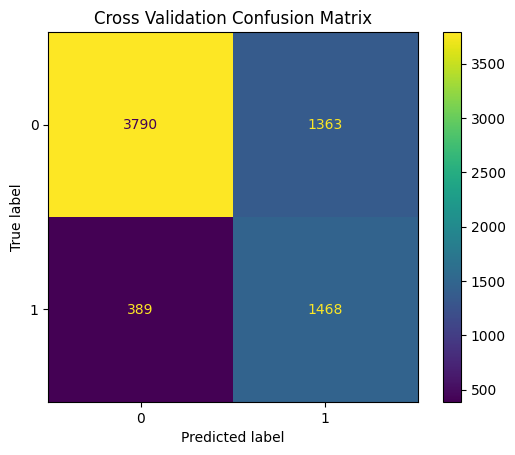

------------------------------------------------------------
KNeighborsClassifier()
Avg. Train Score: 0.7933309557774607
Avg. Test Score: 0.6874465049928673
Avg. Train recall: 0.9208408898314685
Avg. Test recall: 0.7264368315798626
Avg. Train precision: 0.5678180360945835
Avg. Test precision: 0.44502487628287657
Avg. Train F1: 0.7025
Avg. Test F1: 0.5518
Overall F1 Score: 0.5519


<Figure size 600x500 with 0 Axes>

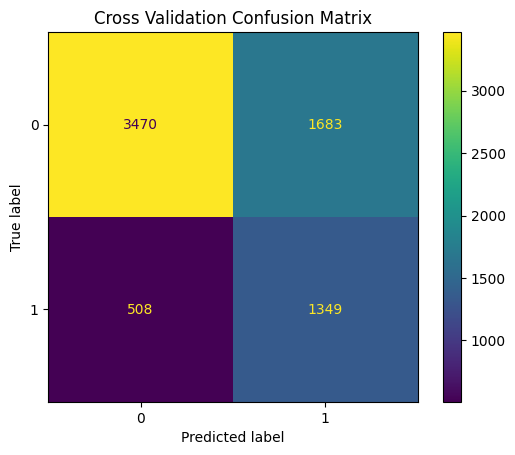

------------------------------------------------------------
GaussianNB()
Avg. Train Score: 0.6616975748930101
Avg. Test Score: 0.6616262482168331
Avg. Train recall: 0.8787035904128772
Avg. Test recall: 0.8761745355476336
Avg. Train precision: 0.43197259182358644
Avg. Test precision: 0.4317721492141011
Avg. Train F1: 0.5792
Avg. Test F1: 0.5784
Overall F1 Score: 0.5784


<Figure size 600x500 with 0 Axes>

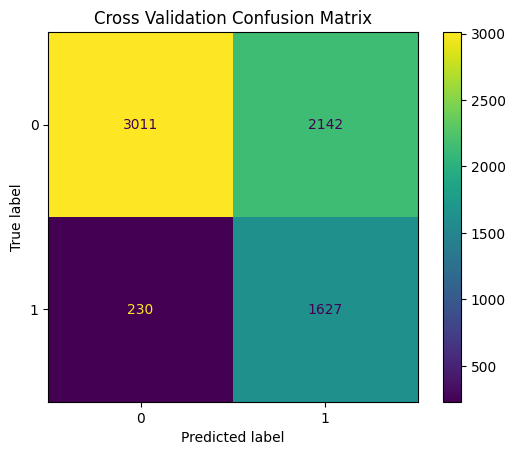

------------------------------------------------------------
MultinomialNB()
Avg. Train Score: 0.6676176890156919
Avg. Test Score: 0.6670470756062767
Avg. Train recall: 0.8708950428465906
Avg. Test recall: 0.8675593426658551
Avg. Train precision: 0.4362440144954246
Avg. Test precision: 0.4354862638508165
Avg. Train F1: 0.5813
Avg. Test F1: 0.5798
Overall F1 Score: 0.5799


<Figure size 600x500 with 0 Axes>

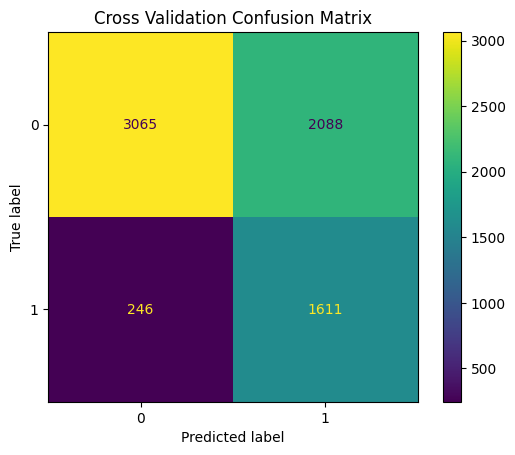

------------------------------------------------------------
BernoulliNB()
Avg. Train Score: 0.6618402282453637
Avg. Test Score: 0.6616262482168331
Avg. Train recall: 0.8699526444344748
Avg. Test recall: 0.867013013361157
Avg. Train precision: 0.43144963403192654
Avg. Test precision: 0.431025468343827
Avg. Train F1: 0.5768
Avg. Test F1: 0.5757
Overall F1 Score: 0.5758


<Figure size 600x500 with 0 Axes>

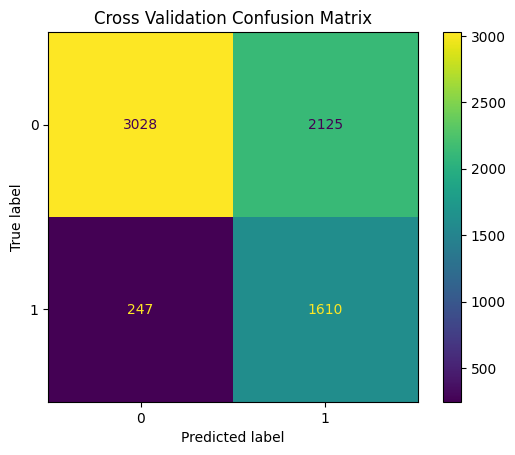

------------------------------------------------------------
ComplementNB()
Avg. Train Score: 0.6676176890156919
Avg. Test Score: 0.6670470756062767
Avg. Train recall: 0.8708950428465906
Avg. Test recall: 0.8675593426658551
Avg. Train precision: 0.4362440144954246
Avg. Test precision: 0.4354862638508165
Avg. Train F1: 0.5813
Avg. Test F1: 0.5798
Overall F1 Score: 0.5799


<Figure size 600x500 with 0 Axes>

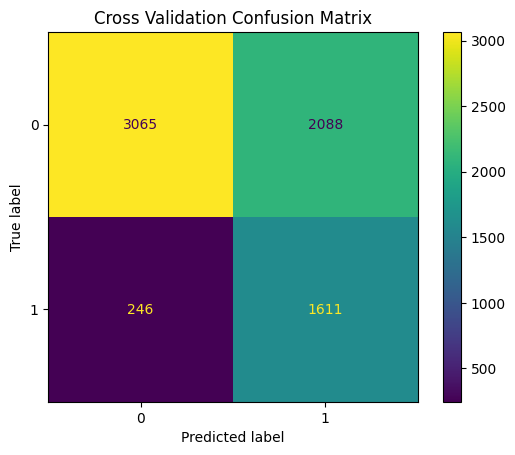

------------------------------------------------------------
CategoricalNB()
Avg. Train Score: 0.6868402282453638
Avg. Test Score: 0.6873038516405134
Avg. Train recall: 0.8525857951429956
Avg. Test recall: 0.8519404109787555
Avg. Train precision: 0.4517694668211899
Avg. Test precision: 0.45210291181919127
Avg. Train F1: 0.5906
Avg. Test F1: 0.5906
Overall F1 Score: 0.5907


<Figure size 600x500 with 0 Axes>

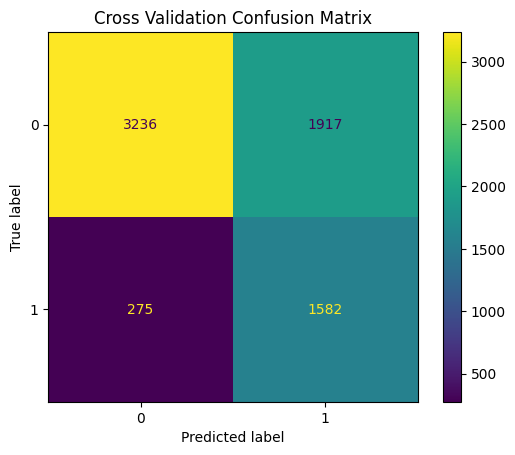

------------------------------------------------------------
SVC(kernel='linear')
Avg. Train Score: 0.7298858773181169
Avg. Test Score: 0.7282453637660484
Avg. Train recall: 0.8134109148913995
Avg. Test recall: 0.8126220908326811
Avg. Train precision: 0.49418293248328105
Avg. Test precision: 0.4926240884712059
Avg. Train F1: 0.6148
Avg. Test F1: 0.6132
Overall F1 Score: 0.6130


<Figure size 600x500 with 0 Axes>

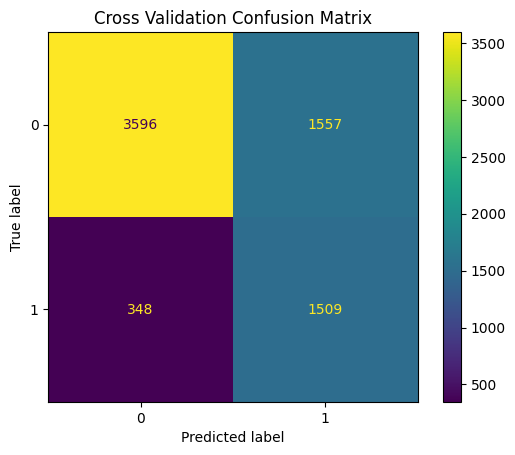

------------------------------------------------------------
SVC()
Avg. Train Score: 0.8016405135520686
Avg. Test Score: 0.7643366619115548
Avg. Train recall: 0.7874293405114401
Avg. Test recall: 0.7146030779932179
Avg. Train precision: 0.5949718365231711
Avg. Test precision: 0.5422505997825062
Avg. Train F1: 0.6777
Avg. Test F1: 0.6165
Overall F1 Score: 0.6163


<Figure size 600x500 with 0 Axes>

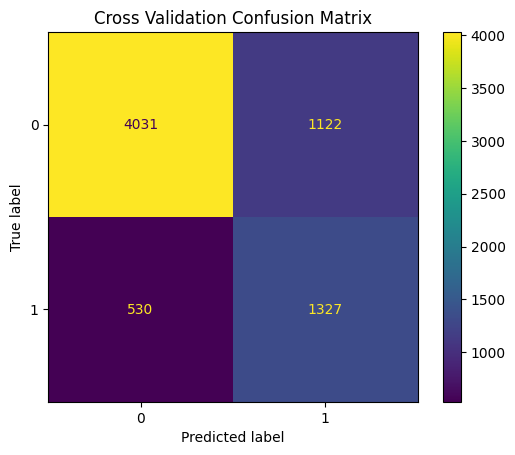

------------------------------------------------------------
SVC(kernel='poly')
Avg. Train Score: 0.7915121255349502
Avg. Test Score: 0.7450784593437947
Avg. Train recall: 0.8288927860933244
Avg. Test recall: 0.7415297220531548
Avg. Train precision: 0.5737294853707832
Avg. Test precision: 0.5134397743734425
Avg. Train F1: 0.6781
Avg. Test F1: 0.6066
Overall F1 Score: 0.6065


<Figure size 600x500 with 0 Axes>

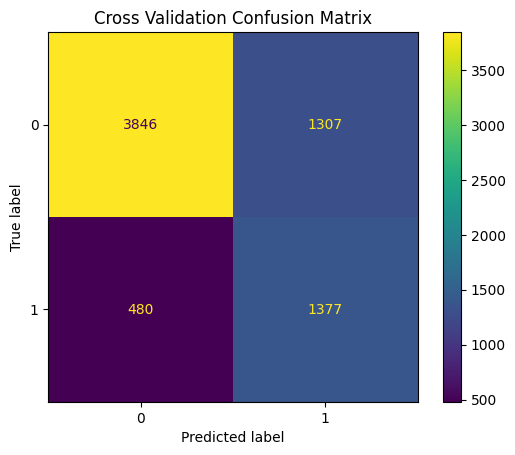

------------------------------------------------------------
SVC(kernel='sigmoid')
Avg. Train Score: 0.6527460770328102
Avg. Test Score: 0.653922967189729
Avg. Train recall: 0.6502418532566581
Avg. Test recall: 0.6462032287047503
Avg. Train precision: 0.4035410365227059
Avg. Test precision: 0.4045013382578393
Avg. Train F1: 0.4980
Avg. Test F1: 0.4974
Overall F1 Score: 0.4973


<Figure size 600x500 with 0 Axes>

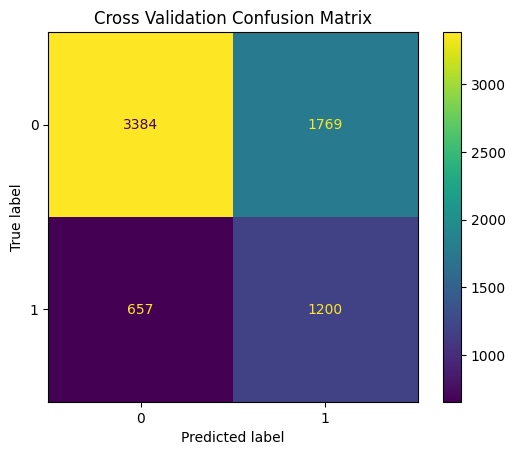

------------------------------------------------------------
DecisionTreeClassifier()
Avg. Train Score: 0.9647289586305279
Avg. Test Score: 0.7238231098430813
Avg. Train recall: 0.9395521840205555
Avg. Test recall: 0.563821986493928
Avg. Train precision: 0.9281777896167988
Avg. Test precision: 0.48198502740950044
Avg. Train F1: 0.9338
Avg. Test F1: 0.5197
Overall F1 Score: 0.5181


<Figure size 600x500 with 0 Axes>

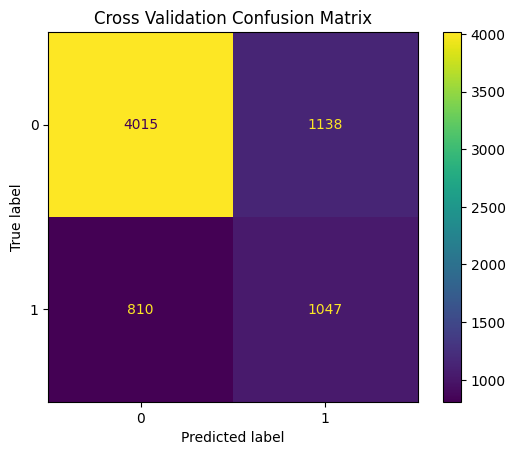

------------------------------------------------------------
RandomForestClassifier()
Avg. Train Score: 0.9639800285306706
Avg. Test Score: 0.7807417974322396
Avg. Train recall: 0.9507271005252163
Avg. Test recall: 0.5955960351273802
Avg. Train precision: 0.916426428559328
Avg. Test precision: 0.5848691898467212
Avg. Train F1: 0.9333
Avg. Test F1: 0.5901
Overall F1 Score: 0.5879


<Figure size 600x500 with 0 Axes>

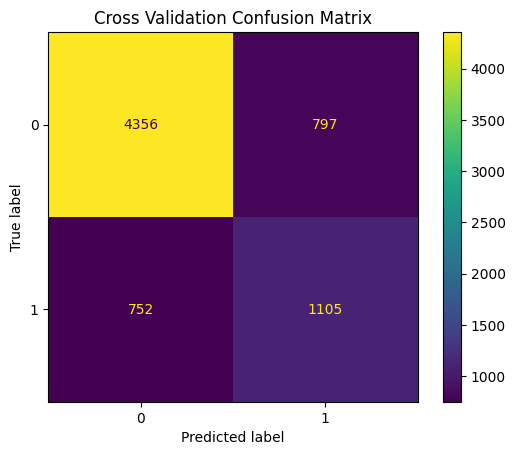

------------------------------------------------------------
AdaBoostClassifier()
Avg. Train Score: 0.7627318116975749
Avg. Test Score: 0.7593437945791726
Avg. Train recall: 0.7812351419080894
Avg. Test recall: 0.7716821725647044
Avg. Train precision: 0.5358992238368498
Avg. Test precision: 0.53202706769911
Avg. Train F1: 0.6356
Avg. Test F1: 0.6297
Overall F1 Score: 0.6295


<Figure size 600x500 with 0 Axes>

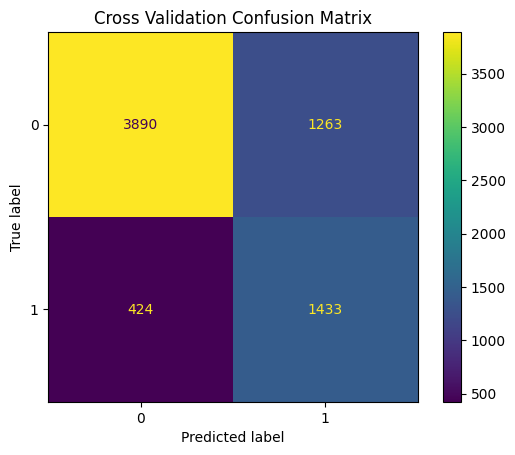

------------------------------------------------------------
GradientBoostingClassifier()
Avg. Train Score: 0.8000713266761768
Avg. Test Score: 0.7810271041369472
Avg. Train recall: 0.725903630291248
Avg. Test recall: 0.6925281859548446
Avg. Train precision: 0.6018086692175622
Avg. Test precision: 0.5719721245691457
Avg. Train F1: 0.6580
Avg. Test F1: 0.6263
Overall F1 Score: 0.6262


<Figure size 600x500 with 0 Axes>

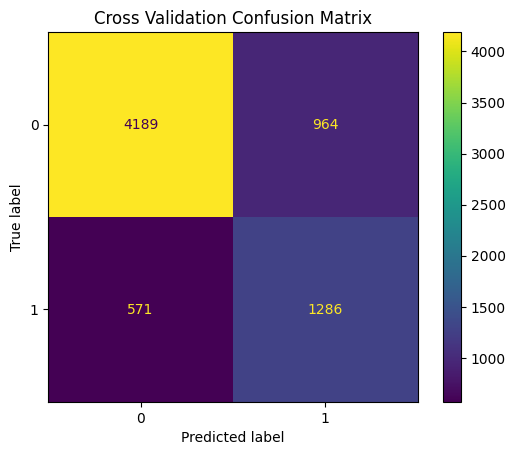

------------------------------------------------------------
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
Avg. Train Score: 0.9099500713266762
Avg. Test Score: 0.779885877318117
Avg. Train recall: 0.8501634560046405
Avg. Test recall: 0.5756687824247166
Avg. Train precision: 0.8172608

<Figure size 600x500 with 0 Axes>

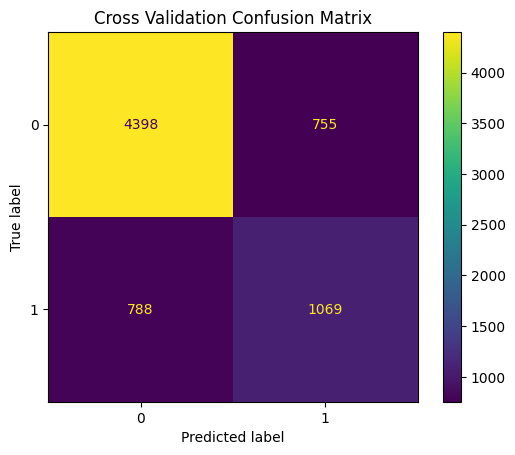

------------------------------------------------------------


In [23]:
for model in models :
    
    Model_pipeline = make_pipeline(copy.deepcopy(preprocessing), SMOTETomek(random_state=3) , model)

    print(model)
    cv = cross_validate(Model_pipeline, x, y, cv= 5, scoring = ['accuracy', 'recall' , 'precision' , 'f1'], return_train_score= True, n_jobs= -1)

    print(f'Avg. Train Score: {cv['train_accuracy'].mean()}')
    print(f'Avg. Test Score: {cv['test_accuracy'].mean()}')


    print(f'Avg. Train recall: {cv['train_recall'].mean()}')
    print(f'Avg. Test recall: {cv['test_recall'].mean()}')

    print(f'Avg. Train precision: {cv['train_precision'].mean()}')
    print(f'Avg. Test precision: {cv['test_precision'].mean()}')
    print(f"Avg. Train F1: {cv['train_f1'].mean():.4f}")
    print(f"Avg. Test F1: {cv['test_f1'].mean():.4f}")

    # Predictions from CV
    y_pred = cross_val_predict(
        Model_pipeline,
        x,
        y,
        cv=5,
        n_jobs=-1
    )

    print(f'Overall F1 Score: {f1_score(y, y_pred):.4f}')

    # Confusion Matrix
    plt.figure(figsize=(6,5))
    ConfusionMatrixDisplay.from_predictions(y, y_pred)
    plt.title('Cross Validation Confusion Matrix')
    plt.show()

    print('-' * 60)
    print('===================================================================')

## Model Selection 2

We compare 4 strong 

- **Logistic Regression**
- **Random Forest**
- **Gradient Boosting**
- **XGBoost**

SMOTE is applied **inside** the pipeline to prevent data leakage.
We optimize for **F1-score** since churn datasets are imbalanced (~26% positive class).

In [24]:
candidates = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced" , random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0),
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running cross-validation for all models...")
print("=" * 60)

for name, model in candidates.items():
    pipe = ImbPipeline([
        ("preprocessor", copy.deepcopy(preprocessing)),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    cv = cross_validate(
        pipe,
        x ,
        y, 
        cv=cv_strategy,
        scoring=["accuracy", "recall", "precision", "f1"],
        return_train_score=True,
        n_jobs=-1
    )


    print(f"\n{name}:")

    print(f"Avg. Train Accuracy: {cv['train_accuracy'].mean():.4f}")
    print(f"Avg. Test Accuracy: {cv['test_accuracy'].mean():.4f}")

    print(f"Avg. Train Recall: {cv['train_recall'].mean():.4f}")
    print(f"Avg. Test Recall: {cv['test_recall'].mean():.4f}")

    print(f"Avg. Train Precision: {cv['train_precision'].mean():.4f}")
    print(f"Avg. Test Precision: {cv['test_precision'].mean():.4f}")

    print(f"Avg. Train F1: {cv['train_f1'].mean():.4f}")
    print(f"Avg. Test F1: {cv['test_f1'].mean():.4f}")

    print("\n" + "=" * 60)

Running cross-validation for all models...

Logistic Regression:
Avg. Train Accuracy: 0.7540
Avg. Test Accuracy: 0.7529
Avg. Train Recall: 0.7948
Avg. Test Recall: 0.7927
Avg. Train Precision: 0.5235
Avg. Test Precision: 0.5222
Avg. Train F1: 0.6312
Avg. Test F1: 0.6296


Random Forest:
Avg. Train Accuracy: 0.9980
Avg. Test Accuracy: 0.7822
Avg. Train Recall: 0.9978
Avg. Test Recall: 0.6026
Avg. Train Precision: 0.9945
Avg. Test Precision: 0.5868
Avg. Train F1: 0.9962
Avg. Test F1: 0.5944


Gradient Boosting:
Avg. Train Accuracy: 0.7996
Avg. Test Accuracy: 0.7849
Avg. Train Recall: 0.7275
Avg. Test Recall: 0.7044
Avg. Train Precision: 0.6005
Avg. Test Precision: 0.5774
Avg. Train F1: 0.6579
Avg. Test F1: 0.6344


XGBoost:
Avg. Train Accuracy: 0.9219
Avg. Test Accuracy: 0.7775
Avg. Train Recall: 0.8708
Avg. Test Recall: 0.5821
Avg. Train Precision: 0.8402
Avg. Test Precision: 0.5798
Avg. Train F1: 0.8552
Avg. Test F1: 0.5808



## Hyperparameter Tuning (XGBoost + RandomizedSearchCV)

In [25]:
Model_pipeline = ImbPipeline([
    ("preprocessing", copy.deepcopy(preprocessing)),
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        verbosity=0
    ))
])

param_dist = {
    "xgb__n_estimators": [100, 200, 300, 400],
    "xgb__max_depth": [3, 4, 5, 6, 7],
    "xgb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "xgb__subsample": [0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "xgb__min_child_weight": [1, 3, 5],
    "xgb__gamma": [0, 0.1, 0.2, 0.5],
    "xgb__scale_pos_weight": [1, 2, 3]
}

random_search = RandomizedSearchCV(
    estimator=Model_pipeline,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1",
    return_train_score=True,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(x, y)

results = pd.DataFrame(random_search.cv_results_)

best_xgb = random_search.best_estimator_
best_idx = random_search.best_index_

print("Train F1:",
      results.loc[best_idx, "mean_train_score"])

print("Test F1:",
      results.loc[best_idx, "mean_test_score"])

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Train F1: 0.6859315561010526
Test F1: 0.6336406049569433


In [26]:
print(random_search.best_params_)

{'xgb__subsample': 0.7, 'xgb__scale_pos_weight': 1, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 3, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0.2, 'xgb__colsample_bytree': 0.6}


## Hyperparameter Tuning (GradientBoosting + RandomizedSearchCV)

In [27]:
Model_pipeline = ImbPipeline([
    ("preprocessing", copy.deepcopy(preprocessing)),
    ("smote", SMOTE(random_state=42)),
    ("gb", GradientBoostingClassifier(
        random_state=42
    ))
])

param_dist = {
    "gb__n_estimators": [50, 100, 150, 200, 300],
    "gb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "gb__max_depth": [2, 3, 4, 5, 6],
    "gb__min_samples_split": [2, 5, 10, 20],
    "gb__min_samples_leaf": [1, 2, 4, 8],
    "gb__subsample": [0.7, 0.8, 0.9, 1.0],
    "gb__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=Model_pipeline,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1",
    return_train_score=True,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(x, y)

results = pd.DataFrame(random_search.cv_results_)

best_idx = random_search.best_index_

print("Best Params:")
print(random_search.best_params_)

print("\nTrain F1:",
      results.loc[best_idx, "mean_train_score"])

print("Test F1:",
      results.loc[best_idx, "mean_test_score"])

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Params:
{'gb__subsample': 0.9, 'gb__n_estimators': 150, 'gb__min_samples_split': 5, 'gb__min_samples_leaf': 8, 'gb__max_features': 'log2', 'gb__max_depth': 2, 'gb__learning_rate': 0.05}

Train F1: 0.6432370202186577
Test F1: 0.6331843929895321


## Hyperparameter Tuning (LogisticRegression + RandomizedSearchCV)

In [28]:
Model_pipeline = ImbPipeline([
    ("preprocessing", copy.deepcopy(preprocessing)),
    ("smote", SMOTE(random_state=42)),
    ("logistic", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

param_dist = {
    "logistic__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "logistic__penalty": ["l1", "l2"],
    "logistic__solver": ["liblinear", "saga"],
    "logistic__class_weight": [None, "balanced"]
}

random_search = RandomizedSearchCV(
    estimator=Model_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    return_train_score=True,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(x, y)

results = pd.DataFrame(random_search.cv_results_)

best_idx = random_search.best_index_

print("Best Params:")
print(random_search.best_params_)

print("\nTrain F1:",
      results.loc[best_idx, "mean_train_score"])

print("Test F1:",
      results.loc[best_idx, "mean_test_score"])

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\myanacondaa\envs\lord\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Params:
{'logistic__solver': 'saga', 'logistic__penalty': 'l2', 'logistic__class_weight': None, 'logistic__C': 1}

Train F1: 0.6342163532794676
Test F1: 0.6301498754992119


## Hyperparameter Tuning (RandomForestClassifier + RandomizedSearchCV)

In [29]:
Model_pipeline = ImbPipeline([
    ("preprocessing", copy.deepcopy(preprocessing)),
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        random_state=42
    ))
])

param_dist = {
    "rf__n_estimators": [100, 200, 300, 500],
    "rf__max_depth": [None, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 20],
    "rf__min_samples_leaf": [1, 2, 4, 8],
    "rf__max_features": ["sqrt", "log2", None],
    "rf__bootstrap": [True, False],
    "rf__class_weight": [None, "balanced", "balanced_subsample"]
}

random_search = RandomizedSearchCV(
    estimator=Model_pipeline,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1",
    return_train_score=True,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(x, y)

results = pd.DataFrame(random_search.cv_results_)

best_idx = random_search.best_index_

print("Best Params:")
print(random_search.best_params_)

print("\nTrain F1:",
      results.loc[best_idx, "mean_train_score"])

print("Test F1:",
      results.loc[best_idx, "mean_test_score"])

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Params:
{'rf__n_estimators': 200, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 8, 'rf__max_features': 'log2', 'rf__max_depth': 10, 'rf__class_weight': 'balanced_subsample', 'rf__bootstrap': False}

Train F1: 0.7047248607075938
Test F1: 0.6313884837273325


## Final Model Evaluation

Avg. Train Score: 0.8084522111269614
Avg. Test Score: 0.7764621968616263
Avg. Train recall: 0.789581322421161
Avg. Test recall: 0.7296974176158594
Avg. Train precision: 0.6063892895171584
Avg. Test precision: 0.5605799938079172
Avg. Train F1: 0.6859
Avg. Test F1: 0.6336


<Figure size 600x500 with 0 Axes>

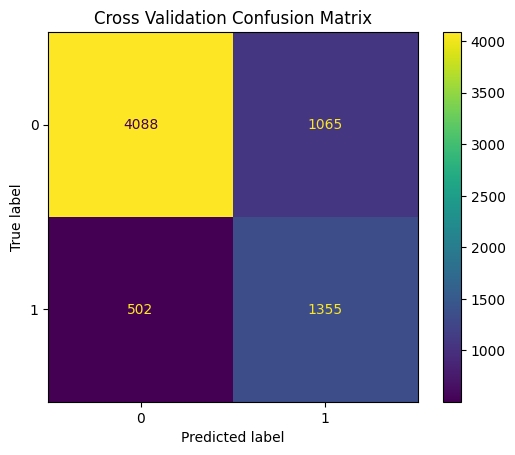

In [30]:
from sklearn.model_selection import cross_validate

cv = cross_validate(
    best_xgb,
    x,
    y,
    cv=5,
    scoring=['accuracy','recall','precision','f1'],
    return_train_score=True,
    n_jobs=-1
)

print(f'Avg. Train Score: {cv['train_accuracy'].mean()}')
print(f'Avg. Test Score: {cv['test_accuracy'].mean()}')


print(f'Avg. Train recall: {cv['train_recall'].mean()}')
print(f'Avg. Test recall: {cv['test_recall'].mean()}')

print(f'Avg. Train precision: {cv['train_precision'].mean()}')
print(f'Avg. Test precision: {cv['test_precision'].mean()}')

print(f"Avg. Train F1: {cv['train_f1'].mean():.4f}")
print(f"Avg. Test F1: {cv['test_f1'].mean():.4f}")

# Predictions from CV
y_pred = cross_val_predict(
    best_xgb,
    x,
    y,
    cv=5,
    n_jobs=-1
)

# Confusion Matrix
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y, y_pred)
plt.title('Cross Validation Confusion Matrix')
plt.show()

In [32]:
# Save best model

joblib.dump(
    best_xgb,
    "xgb_churn_model.pkl"
)

['xgb_churn_model.pkl']

## Conclusion

After evaluating and tuning multiple machine learning models, **XGBoost** was selected as the final model, achieving an **F1-Score of approximately 0.63** on cross-validation. This model provided the best overall balance between Precision and Recall for predicting customer churn.